In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib, json, warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve, f1_score,
    ConfusionMatrixDisplay
)
from xgboost import XGBClassifier
import shap

plt.style.use('seaborn-v0_8-whitegrid')
print("All libraries loaded.")

All libraries loaded.


In [2]:
# Use the provided modeling snapshot (recommended)
df = pd.read_csv('data/modeling_snapshot.csv')
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nDtypes:\n", df.dtypes.to_string())
df.head(3)

Shape: (2400, 29)

Columns: ['customer_id', 'snapshot_date', 'city_tier', 'age_group', 'acquisition_channel', 'loyalty_tier', 'preferred_category', 'marketing_consent', 'recency_days', 'frequency_180d', 'monetary_180d', 'return_rate_180d', 'avg_discount_pct_180d', 'avg_rating_180d', 'category_diversity_180d', 'ticket_count_90d', 'negative_ticket_rate_90d', 'avg_resolution_hours_90d', 'days_since_signup', 'sessions_30d', 'product_views_30d', 'cart_adds_30d', 'wishlist_adds_30d', 'abandoned_carts_30d', 'email_opens_30d', 'campaign_clicks_30d', 'last_visit_days_ago', 'churn_next_60d', 'split']

Dtypes:
 customer_id                     str
snapshot_date                   str
city_tier                       str
age_group                       str
acquisition_channel             str
loyalty_tier                    str
preferred_category              str
marketing_consent               str
recency_days                  int64
frequency_180d                int64
monetary_180d               floa

,customer_id,snapshot_date,city_tier,age_group,acquisition_channel,loyalty_tier,preferred_category,marketing_consent,recency_days,frequency_180d,...,sessions_30d,product_views_30d,cart_adds_30d,wishlist_adds_30d,abandoned_carts_30d,email_opens_30d,campaign_clicks_30d,last_visit_days_ago,churn_next_60d,split
0,CUST00001,2025-09-30,Tier 1,18-24,Instagram,Silver,Makeup,Yes,107,1,...,1,4,0,0,0,2,0,20,1,train
1,CUST00002,2025-09-30,Tier 2,25-34,Marketplace,Silver,Hair Care,Yes,40,1,...,8,31,4,2,3,0,0,0,0,train
2,CUST00003,2025-09-30,Tier 1,25-34,Influencer,NaN,Skin Care,Yes,171,1,...,1,3,0,0,0,0,0,26,1,train


In [3]:
print("=== LEAKAGE CHECK ===")

# Flag columns that may contain future information
suspicious = [c for c in df.columns if any(kw in c.lower() for kw in
              ['next','future','after','post','churn_date','days_to_churn',
               'churn_reason','target_window']) and c != 'churn_next_60d']
print("Suspicious columns to review:", suspicious)

# Flag columns with 'churn' in name (other than the target)
churn_cols = [c for c in df.columns if 'churn' in c.lower() and c != 'churn_next_60d']
print("Churn-related columns (review before using):", churn_cols)

# Show unique values of any date columns
date_cols = df.select_dtypes(include=['datetime64', 'object']).columns.tolist()
# Note: snapshot_date is the only date column and it's already in the drop list
print("Date columns:", date_cols)

print("\n✅ Only use columns representing behaviour BEFORE the snapshot date.")

=== LEAKAGE CHECK ===
Suspicious columns to review: []
Churn-related columns (review before using): []
Date columns: ['customer_id', 'snapshot_date', 'city_tier', 'age_group', 'acquisition_channel', 'loyalty_tier', 'preferred_category', 'marketing_consent', 'split']

✅ Only use columns representing behaviour BEFORE the snapshot date.


In [4]:
TARGET  = 'churn_next_60d'
DROP    = ['customer_id', 'snapshot_date', TARGET]

# Drop identified leakage columns too
LEAKAGE = []  # No extra leakage found
ALL_DROP = DROP + LEAKAGE

X = df.drop(columns=ALL_DROP, errors='ignore')
y = df[TARGET]

# Encode categoricals
cat_cols = X.select_dtypes(include='object').columns.tolist()
print("Categorical columns to encode:", cat_cols)

le_dict = {}
for col in cat_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    le_dict[col] = le

# Fill missing with median
X = X.fillna(X.median(numeric_only=True))

print(f"\nFinal feature shape: {X.shape}")
print(f"Target distribution:\n{y.value_counts()}")
print(f"Churn rate: {y.mean()*100:.1f}%")

Categorical columns to encode: ['city_tier', 'age_group', 'acquisition_channel', 'loyalty_tier', 'preferred_category', 'marketing_consent', 'split']

Final feature shape: (2400, 26)
Target distribution:
churn_next_60d
0    1273
1    1127
Name: count, dtype: int64
Churn rate: 47.0%


In [5]:
if 'split' in df.columns:
    # Use provided split
    X_train = X[df['split'] == 'train']
    y_train = y[df['split'] == 'train']
    X_val   = X[df['split'] == 'validation'] # FIX: The dataset uses 'validation' not 'val'
    y_val   = y[df['split'] == 'validation']
    X_test  = X[df['split'] == 'test']
    y_test  = y[df['split'] == 'test']
    print("Using provided split column.")
    
    # We must drop the split column from X
    X_train = X_train.drop(columns=['split'], errors='ignore')
    X_val   = X_val.drop(columns=['split'], errors='ignore')
    X_test  = X_test.drop(columns=['split'], errors='ignore')
else:
    # Manual 70/15/15 stratified split
    X_temp, X_test, y_temp, y_test = train_test_split(
        X, y, test_size=0.15, random_state=42, stratify=y)
    X_train, X_val, y_train, y_val = train_test_split(
        X_temp, y_temp, test_size=0.176, random_state=42, stratify=y_temp)
    print("Using manual 70/15/15 split.")

print(f"\nTrain : {X_train.shape[0]:,} rows ({y_train.mean()*100:.1f}% churn)")
print(f"Val   : {X_val.shape[0]:,} rows ({y_val.mean()*100:.1f}% churn)")
print(f"Test  : {X_test.shape[0]:,} rows ({y_test.mean()*100:.1f}% churn)")

Using provided split column.

Train : 1,728 rows (47.0% churn)
Val   : 336 rows (43.8% churn)
Test  : 336 rows (50.0% churn)


In [6]:
baseline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',    LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        random_state=42
    ))
])

baseline.fit(X_train, y_train)
y_pred_base = baseline.predict(X_val)
y_prob_base = baseline.predict_proba(X_val)[:, 1]

print("=" * 50)
print("BASELINE MODEL: Logistic Regression")
print("=" * 50)
print(classification_report(y_val, y_pred_base, target_names=['Retained','Churned']))
print(f"ROC-AUC : {roc_auc_score(y_val, y_prob_base):.4f}")
print(f"PR-AUC  : {average_precision_score(y_val, y_prob_base):.4f}")

BASELINE MODEL: Logistic Regression
              precision    recall  f1-score   support

    Retained       0.84      0.86      0.85       189
     Churned       0.82      0.78      0.80       147

    accuracy                           0.83       336
   macro avg       0.83      0.82      0.82       336
weighted avg       0.83      0.83      0.83       336

ROC-AUC : 0.8846
PR-AUC  : 0.8690


In [7]:
# Handle class imbalance
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_ratio = neg / pos
print(f"Class ratio (neg/pos): {scale_ratio:.2f}")

xgb = XGBClassifier(
    n_estimators      = 500,
    max_depth         = 6,
    learning_rate     = 0.05,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    scale_pos_weight  = scale_ratio,
    min_child_weight  = 5,
    random_state      = 42,
    eval_metric       = 'logloss',
    early_stopping_rounds = 30,
    verbosity         = 0
)

xgb.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

y_pred_xgb = xgb.predict(X_val)
y_prob_xgb = xgb.predict_proba(X_val)[:, 1]

print("=" * 50)
print("STRONGER MODEL: XGBoost")
print("=" * 50)
print(classification_report(y_val, y_pred_xgb, target_names=['Retained','Churned']))
print(f"ROC-AUC : {roc_auc_score(y_val, y_prob_xgb):.4f}")
print(f"PR-AUC  : {average_precision_score(y_val, y_prob_xgb):.4f}")

Class ratio (neg/pos): 1.13


STRONGER MODEL: XGBoost
              precision    recall  f1-score   support

    Retained       0.83      0.84      0.83       189
     Churned       0.79      0.78      0.78       147

    accuracy                           0.81       336
   macro avg       0.81      0.81      0.81       336
weighted avg       0.81      0.81      0.81       336

ROC-AUC : 0.8840
PR-AUC  : 0.8545


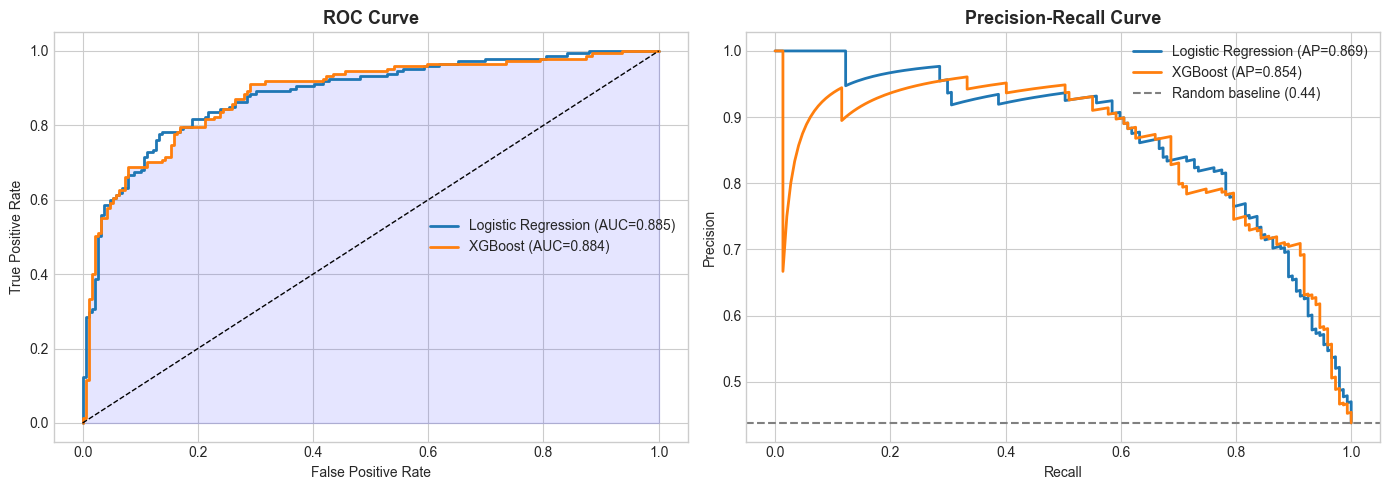

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC Curve
for name, probs in [('Logistic Regression', y_prob_base), ('XGBoost', y_prob_xgb)]:
    fpr, tpr, _ = roc_curve(y_val, probs)
    auc = roc_auc_score(y_val, probs)
    axes[0].plot(fpr, tpr, linewidth=2, label=f'{name} (AUC={auc:.3f})')
axes[0].plot([0,1],[0,1],'k--', linewidth=1)
axes[0].fill_between(*roc_curve(y_val, y_prob_xgb)[:2],
                     alpha=0.1, color='blue')
axes[0].set_title('ROC Curve', fontsize=13, fontweight='bold')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend()

# PR Curve
for name, probs in [('Logistic Regression', y_prob_base), ('XGBoost', y_prob_xgb)]:
    prec, rec, _ = precision_recall_curve(y_val, probs)
    ap = average_precision_score(y_val, probs)
    axes[1].plot(rec, prec, linewidth=2, label=f'{name} (AP={ap:.3f})')
baseline_pr = y_val.mean()
axes[1].axhline(baseline_pr, color='gray', linestyle='--',
                label=f'Random baseline ({baseline_pr:.2f})')
axes[1].set_title('Precision-Recall Curve', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend()

plt.tight_layout()
plt.savefig('charts/01_roc_pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
# Business logic: Missing a churner (FN) costs more than flagging a non-churner (FP)
# Goal: Recall >= 0.75 with highest possible F1

thresholds = np.arange(0.10, 0.90, 0.05)
rows = []
for t in thresholds:
    preds = (y_prob_xgb >= t).astype(int)
    rep   = classification_report(y_val, preds, output_dict=True, zero_division=0)
    rows.append({
        'threshold' : round(t, 2),
        'precision' : rep['1']['precision'],
        'recall'    : rep['1']['recall'],
        'f1'        : rep['1']['f1-score'],
        'accuracy'  : rep['accuracy']
    })

thr_df = pd.DataFrame(rows)
print(thr_df.to_string(index=False))

# Select threshold: recall >= 0.75, highest F1
candidates = thr_df[thr_df['recall'] >= 0.75]
if len(candidates) > 0:
    best = candidates.sort_values('f1', ascending=False).iloc[0]
else:
    best = thr_df.sort_values('f1', ascending=False).iloc[0]

THRESHOLD = best['threshold']
print(f"\n✅ Selected threshold: {THRESHOLD}")
print(f"   Recall   : {best['recall']:.3f}")
print(f"   Precision: {best['precision']:.3f}")
print(f"   F1-Score : {best['f1']:.3f}")

 threshold  precision   recall       f1  accuracy
      0.10   0.523985 0.965986 0.679426  0.601190
      0.15   0.578512 0.952381 0.719794  0.675595
      0.20   0.615044 0.945578 0.745308  0.717262
      0.25   0.642857 0.918367 0.756303  0.741071
      0.30   0.701571 0.911565 0.792899  0.791667
      0.35   0.719101 0.870748 0.787692  0.794643
      0.40   0.728916 0.823129 0.773163  0.788690
      0.45   0.759740 0.795918 0.777409  0.800595
      0.50   0.791667 0.775510 0.783505  0.812500
      0.55   0.786765 0.727891 0.756184  0.794643
      0.60   0.811024 0.700680 0.751825  0.797619
      0.65   0.841667 0.687075 0.756554  0.806548
      0.70   0.873874 0.659864 0.751938  0.809524
      0.75   0.896907 0.591837 0.713115  0.791667
      0.80   0.931034 0.551020 0.692308  0.785714
      0.85   0.945946 0.476190 0.633484  0.758929

✅ Selected threshold: 0.3
   Recall   : 0.912
   Precision: 0.702
   F1-Score : 0.793


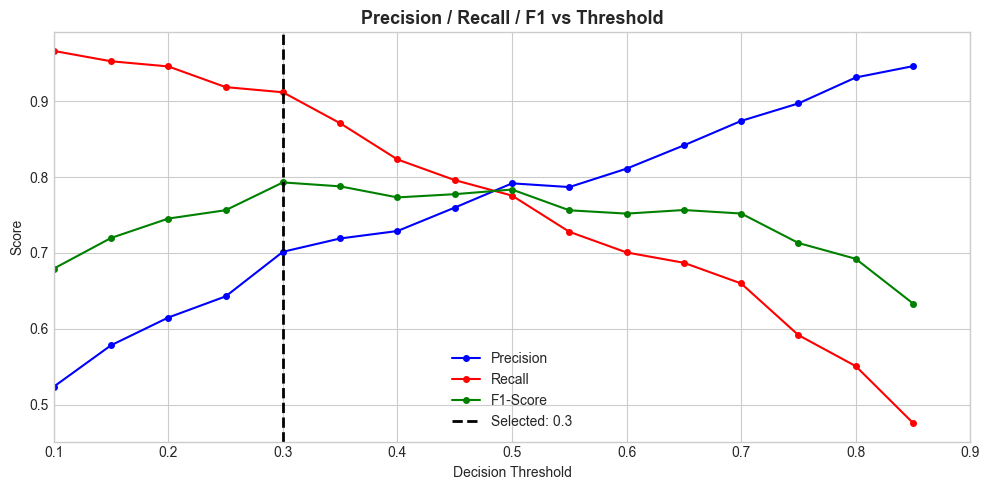

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thr_df['threshold'], thr_df['precision'], 'b-o', markersize=4, label='Precision')
ax.plot(thr_df['threshold'], thr_df['recall'],    'r-o', markersize=4, label='Recall')
ax.plot(thr_df['threshold'], thr_df['f1'],        'g-o', markersize=4, label='F1-Score')
ax.axvline(THRESHOLD, color='black', linestyle='--', linewidth=2,
           label=f'Selected: {THRESHOLD}')
ax.set_title('Precision / Recall / F1 vs Threshold', fontsize=13, fontweight='bold')
ax.set_xlabel('Decision Threshold')
ax.set_ylabel('Score')
ax.legend()
ax.set_xlim(0.1, 0.9)
plt.tight_layout()
plt.savefig('charts/02_threshold_selection.png', dpi=150, bbox_inches='tight')
plt.show()

FINAL EVALUATION — TEST SET
              precision    recall  f1-score   support

    Retained       0.89      0.62      0.73       168
     Churned       0.71      0.92      0.80       168

    accuracy                           0.77       336
   macro avg       0.80      0.77      0.77       336
weighted avg       0.80      0.77      0.77       336



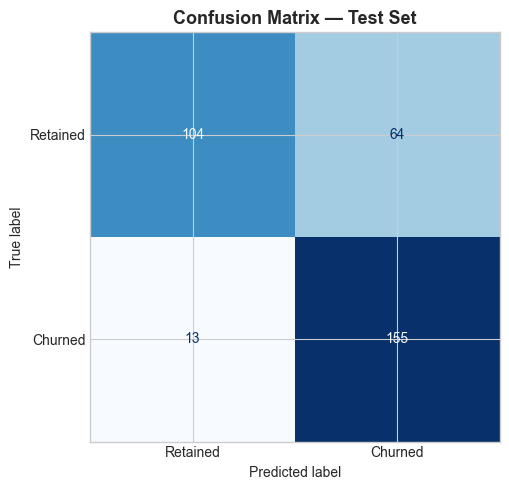


ROC-AUC : 0.8723
PR-AUC  : 0.8550


In [11]:
y_prob_test = xgb.predict_proba(X_test)[:, 1]
y_pred_test = (y_prob_test >= THRESHOLD).astype(int)

print("=" * 50)
print("FINAL EVALUATION — TEST SET")
print("=" * 50)
report = classification_report(y_test, y_pred_test,
                                target_names=['Retained','Churned'],
                                output_dict=True)
print(classification_report(y_test, y_pred_test, target_names=['Retained','Churned']))

cm = confusion_matrix(y_test, y_pred_test)
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Retained','Churned'])
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix — Test Set', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('charts/03_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nROC-AUC : {roc_auc_score(y_test, y_prob_test):.4f}")
print(f"PR-AUC  : {average_precision_score(y_test, y_prob_test):.4f}")

In [12]:
metrics = {
    "model"          : "XGBoost",
    "threshold"      : float(THRESHOLD),
    "accuracy"       : round(report['accuracy'], 4),
    "precision_churn": round(report['Churned']['precision'], 4),
    "recall_churn"   : round(report['Churned']['recall'], 4),
    "f1_churn"       : round(report['Churned']['f1-score'], 4),
    "roc_auc"        : round(roc_auc_score(y_test, y_prob_test), 4),
    "pr_auc"         : round(average_precision_score(y_test, y_prob_test), 4),
    "confusion_matrix": {
        "TN": int(cm[0][0]),
        "FP": int(cm[0][1]),
        "FN": int(cm[1][0]),
        "TP": int(cm[1][1])
    }
}

with open('metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)

print("Saved metrics.json:")
print(json.dumps(metrics, indent=2))

Saved metrics.json:
{
  "model": "XGBoost",
  "threshold": 0.3,
  "accuracy": 0.7708,
  "precision_churn": 0.7078,
  "recall_churn": 0.9226,
  "f1_churn": 0.801,
  "roc_auc": 0.8723,
  "pr_auc": 0.855,
  "confusion_matrix": {
    "TN": 104,
    "FP": 64,
    "FN": 13,
    "TP": 155
  }
}


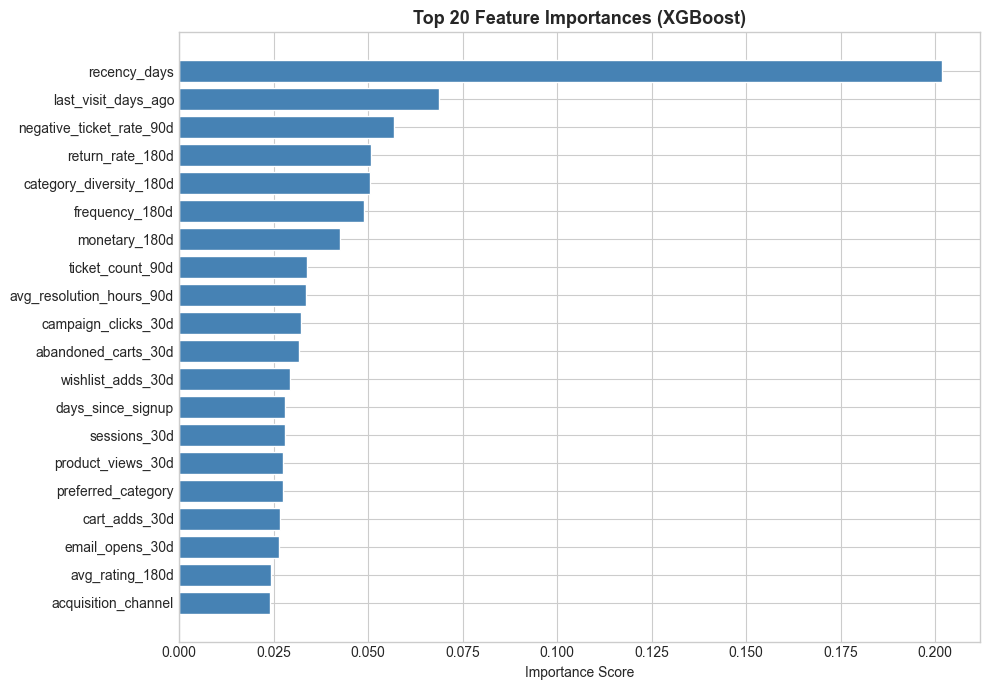


Top 10 Features:
                 feature  importance
            recency_days    0.201737
     last_visit_days_ago    0.068776
negative_ticket_rate_90d    0.056853
        return_rate_180d    0.050762
 category_diversity_180d    0.050389
          frequency_180d    0.048976
           monetary_180d    0.042711
        ticket_count_90d    0.033893
avg_resolution_hours_90d    0.033479
     campaign_clicks_30d    0.032375


In [13]:
feat_importance = pd.DataFrame({
    'feature'   : X_train.columns,
    'importance': xgb.feature_importances_
}).sort_values('importance', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(feat_importance['feature'][::-1],
               feat_importance['importance'][::-1],
               color='steelblue', edgecolor='white')
ax.set_title('Top 20 Feature Importances (XGBoost)', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig('charts/04_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 10 Features:")
print(feat_importance.head(10).to_string(index=False))

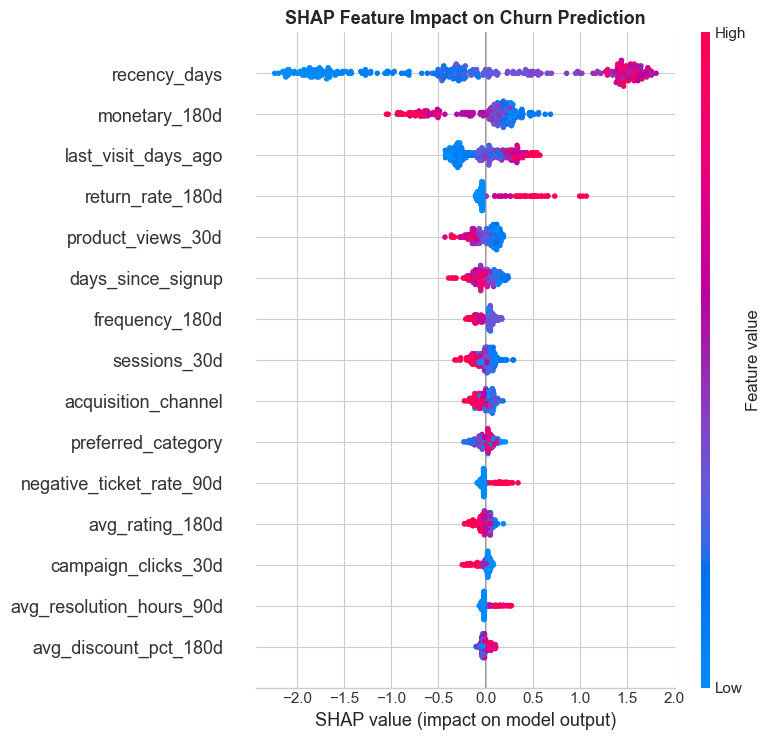

In [14]:
explainer   = shap.TreeExplainer(xgb)
sample_size = min(300, len(X_test))
X_sample    = X_test.iloc[:sample_size]
shap_values = explainer.shap_values(X_sample)

# Summary plot
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_sample, show=False, max_display=15)
plt.title('SHAP Feature Impact on Churn Prediction', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('charts/05_shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

In [15]:
# Build error analysis dataframe
error_df = X_test.copy()
error_df['customer_id']    = df.loc[X_test.index, 'customer_id'].values
error_df['actual_churn']   = y_test.values
error_df['churn_prob']     = y_prob_test
error_df['predicted_churn']= y_pred_test

# False Positives: predicted churn, actually stayed
FP = error_df[(error_df['predicted_churn']==1) & (error_df['actual_churn']==0)]
FP = FP.sort_values('churn_prob', ascending=False)

# False Negatives: predicted stayed, actually churned
FN = error_df[(error_df['predicted_churn']==0) & (error_df['actual_churn']==1)]
FN = FN.sort_values('churn_prob', ascending=False)

print(f"False Positives: {len(FP):,}")
print(f"False Negatives: {len(FN):,}")
print("\nTop 5 False Positives:")
print(FP[['customer_id','churn_prob','actual_churn']].head(5).to_string(index=False))
print("\nTop 5 False Negatives:")
print(FN[['customer_id','churn_prob','actual_churn']].head(5).to_string(index=False))

# Save for manual review
FP.head(10).to_csv('fp_examples.csv', index=False)
FN.head(10).to_csv('fn_examples.csv', index=False)

False Positives: 64
False Negatives: 13

Top 5 False Positives:
customer_id  churn_prob  actual_churn
  CUST01370    0.928688             0
  CUST01246    0.908391             0
  CUST00437    0.905519             0
  CUST01017    0.904460             0
  CUST01325    0.889036             0

Top 5 False Negatives:
customer_id  churn_prob  actual_churn
  CUST00938    0.296123             1
  CUST00438    0.288176             1
  CUST00247    0.282124             1
  CUST00838    0.214041             1
  CUST02072    0.190082             1


In [16]:
joblib.dump(xgb, 'model.pkl')
print("Model saved as model.pkl")

# Verify reload works
loaded_model = joblib.load('model.pkl')
test_preds   = loaded_model.predict_proba(X_test.iloc[:3])[:, 1]
print("Reload check — first 3 probabilities:", test_preds.round(4))

Model saved as model.pkl
Reload check — first 3 probabilities: [0.909  0.904  0.0554]
